<a href="https://colab.research.google.com/github/Dandyeriametor/Activity/blob/main/Assignment_6_House_Price_Prediction_Using_California_Housing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 6 — ML Basics Assignment: California Housing
Author: Dandy Eriametor

Business Intelligence Analyst

Student Number: DE111080

This notebook completes the assignment using scikit-learn's **California Housing** dataset.

**Sections**:
1. Imports
2. Data Loading
3. Quick Check of Data
4. EDA & Preprocessing
5. Model Training
6. Model Evaluation
7. Model Prediction


## 1) Imports

In [1]:
# Import all the required Librabries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2) Data Collection and Loading

In [4]:
# Attempt to fetch the California Housing dataset.
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# Clarify target name
target_col = 'MedHouseVal'
feature_names = list(data.feature_names)

print("Dataset shape:", df.shape)
print("Features:", feature_names)
print("Target:", target_col)

# Show first few rows
df.head()

Dataset shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3) Quick Check of Data

In [5]:
print("\nDataFrame Info:")
print(df.info())

print("\nDescribe (features & target):")
df.describe(include='all')


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Describe (features & target):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# All features in California Housing are numeric (continuous).
# There are no categorical features in this dataset.
df.dtypes.to_frame('dtype')

,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


## 4) EDA and Data Preprocessing

In [7]:
# Missing/null values
missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts)
assert missing_counts.sum() == 0, "Dataset unexpectedly contains missing values."
missing_counts

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


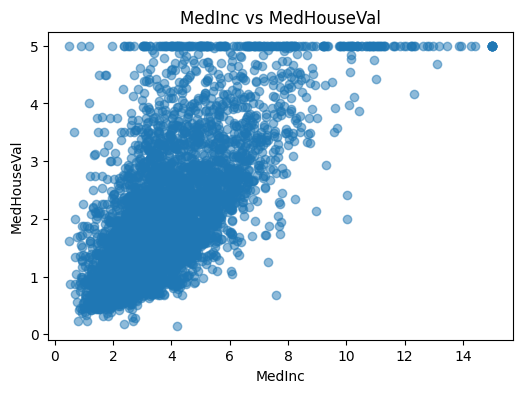

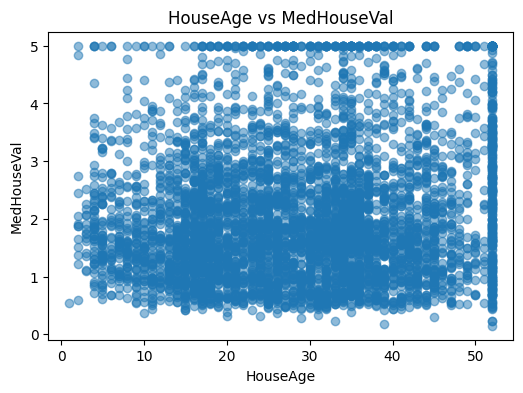

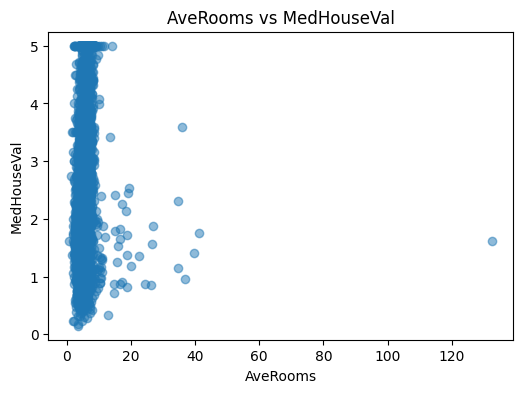

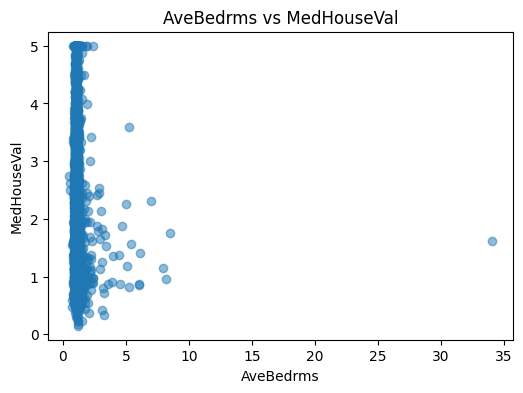

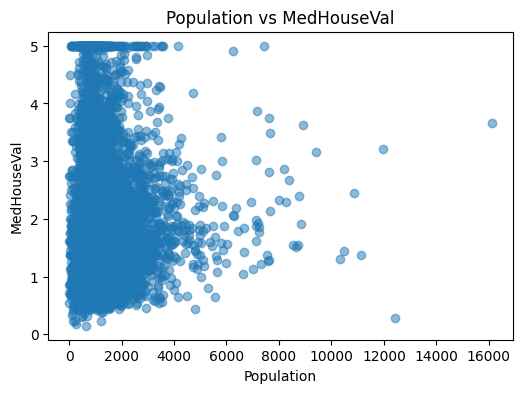

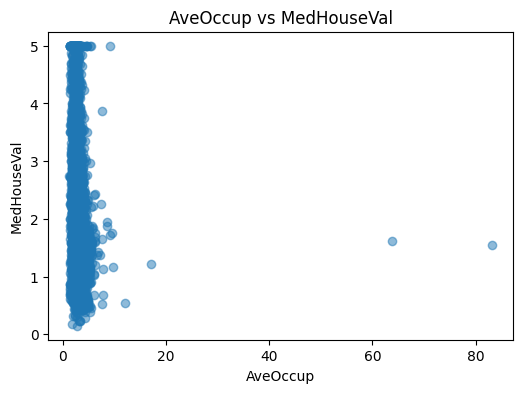

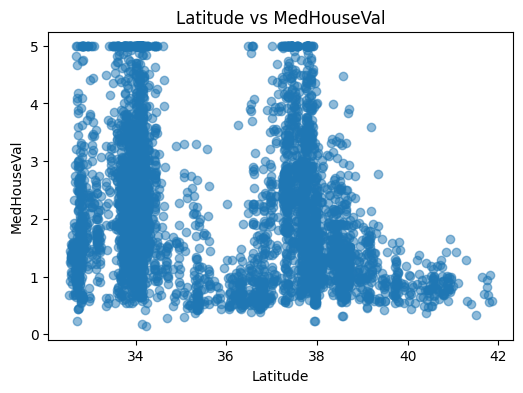

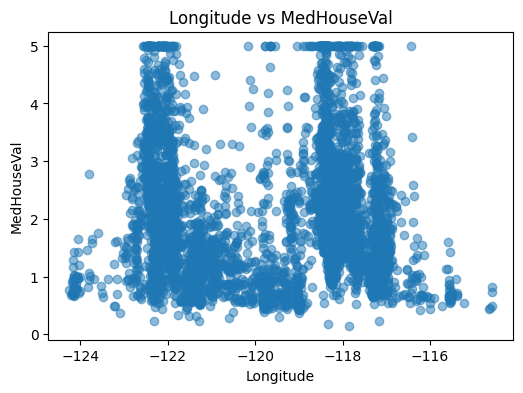

In [13]:
# Scatter plots: function to automate feature vs target
for feat in feature_names:
    scatter_feature_vs_target(df, feat, target=target_col)
def scatter_feature_vs_target(data, feature, target='MedHouseVal', sample=5000):
    # Randomly sample data for faster plotting if dataset is large
    if sample is not None and len(data) > sample:
        d = data.sample(sample, random_state=42)
    else:
        d = data

    # Create scatter plot
    plt.figure(figsize=(6, 4))
    plt.scatter(d[feature], d[target], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{feature} vs {target}")
    plt.show()

## 5) ML Model Training

In [14]:
X = df[feature_names]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose a simple, strong baseline model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained: LinearRegression")
print("Intercept:", model.intercept_)
print("Coefficients:")
for f, c in zip(feature_names, model.coef_):
    print(f"  {f}: {c}")

Model trained: LinearRegression
Intercept: -37.02327770606409
Coefficients:
  MedInc: 0.44867490966571666
  HouseAge: 0.009724257517904806
  AveRooms: -0.12332334282795815
  AveBedrms: 0.7831449067929722
  Population: -2.029620580100075e-06
  AveOccup: -0.003526318487134238
  Latitude: -0.4197924865883604
  Longitude: -0.433708064963987


## 6) Model Evaluation

RMSE: 0.7456
R^2 : 0.5758


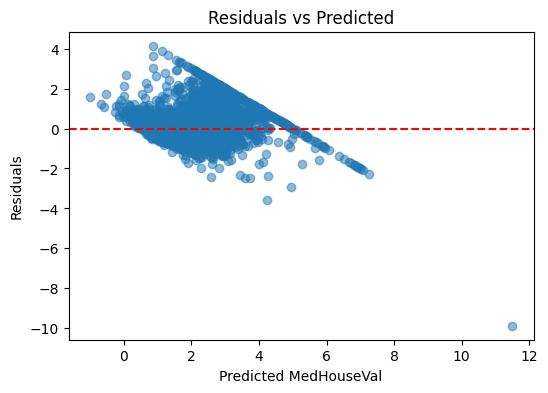

,Metric,Value
0,RMSE,0.745581
1,R²,0.575788


In [17]:
y_pred = model.predict(X_test)

# Calculate metrics (compatible with all sklearn versions)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display metrics
print(f"RMSE: {rmse:.4f}")
print(f"R^2 : {r2:.4f}")

# Residuals vs Predicted plot (display only)
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Display results as a DataFrame
pd.DataFrame({
    "Metric": ["RMSE", "R²"],
    "Value": [rmse, r2]
})



## 7) Model Prediction

In [18]:
def predict_med_house_val(model, feature_values: dict, ordered_features):
    x = np.array([[feature_values[f] for f in ordered_features]], dtype=float)
    return float(model.predict(x)[0])

# Example: feature means
new_input = {f: float(df[f].mean()) for f in feature_names}
pred_means = predict_med_house_val(model, new_input, feature_names)

# Example: a custom input
custom_input = {
    'MedInc': 5.0,
    'HouseAge': 30.0,
    'AveRooms': 5.5,
    'AveBedrms': 1.0,
    'Population': 1000.0,
    'AveOccup': 3.0,
    'Latitude': 34.0,
    'Longitude': -118.0
}
pred_custom = predict_med_house_val(model, custom_input, feature_names)

pd.DataFrame([
    {"Input": "means", "Predicted_MedHouseVal": pred_means},
    {"Input": "custom_example", "Predicted_MedHouseVal": pred_custom}
])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Input,Predicted_MedHouseVal
0,means,2.067862
1,custom_example,2.508690
